In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("smartcart_customers(1).csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle missing values

In [8]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## 2. Feature Engineering

In [13]:
#Age

df["Age"] = 2026-df["Year_Birth"]

In [19]:
#Customer Joining Date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [24]:
#Spending

df["Total_Spending"] = df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [27]:
#Children

df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [30]:
#Education

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate","Master":"Postgraduate"
})

df["Education"].value_counts()
#Undergraduate,Graduate,PostGraduate

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [33]:
#Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## 3.Drop Columns

In [38]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]

spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols+spending_cols
df_cleaned = df.drop(columns = cols_to_drop)


In [39]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

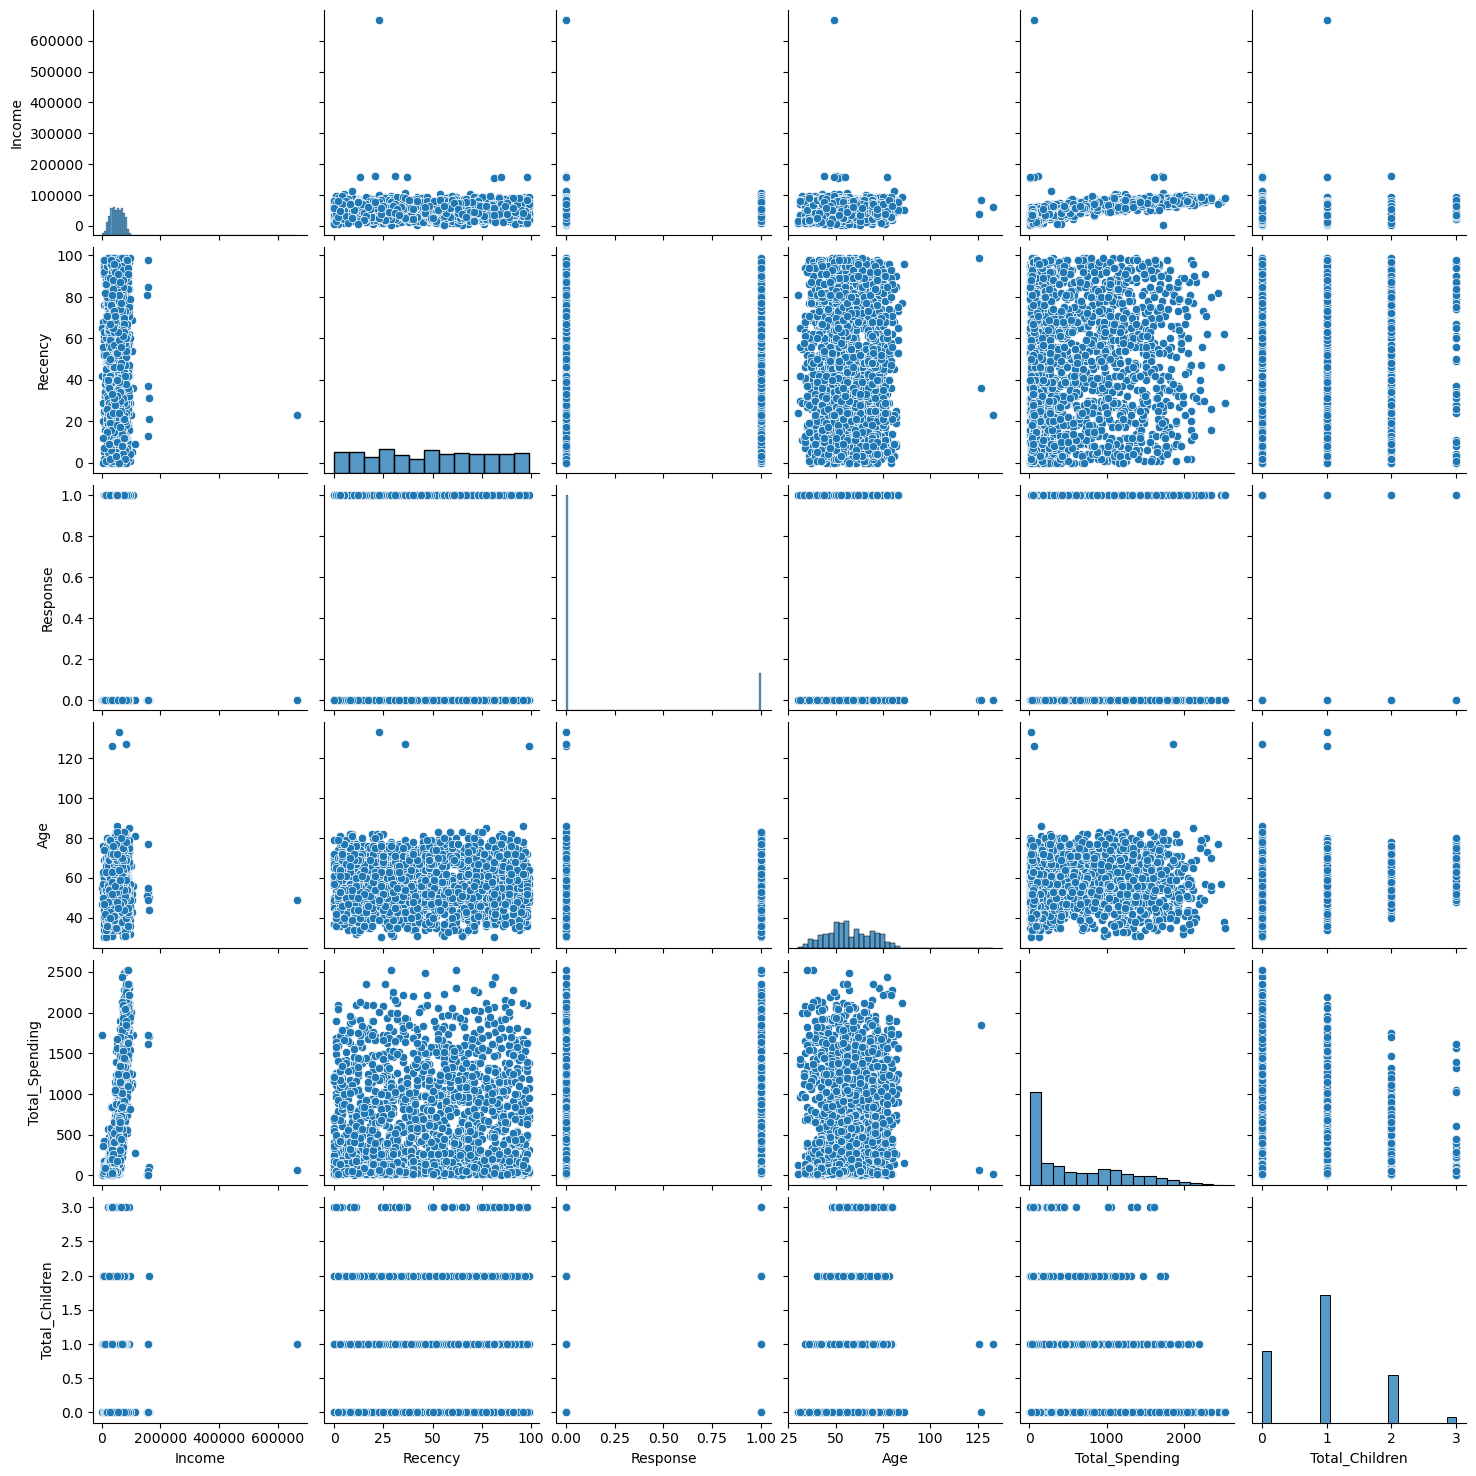

In [40]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#relative plots of some features---pair plots
sns.pairplot(df_cleaned[cols])

In [41]:
# Remove outliers

print("Data size with outlier",len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"]<90]
df_cleaned = df_cleaned[df_cleaned["Income"]<600000]

print("Data size without outlier",len(df_cleaned))

Data size with outlier 2240
Data size without outlier 2236


# Heatmap

In [42]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

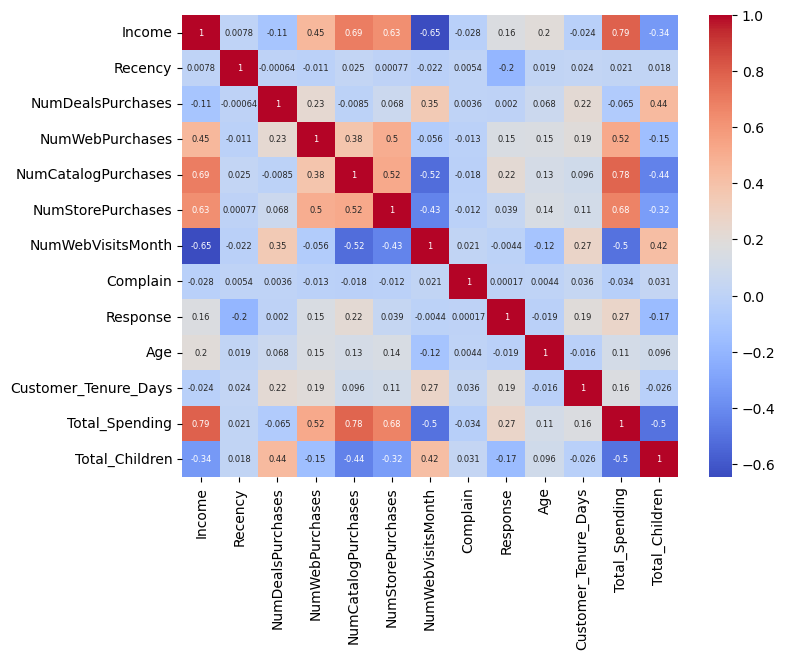

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)

# Encoding

In [46]:
from sklearn.preprocessing import OneHotEncoder

In [47]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [50]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [54]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [55]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [57]:
from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualise

In [58]:
from sklearn.decomposition import PCA

In [65]:
#3D

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [66]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection of features')

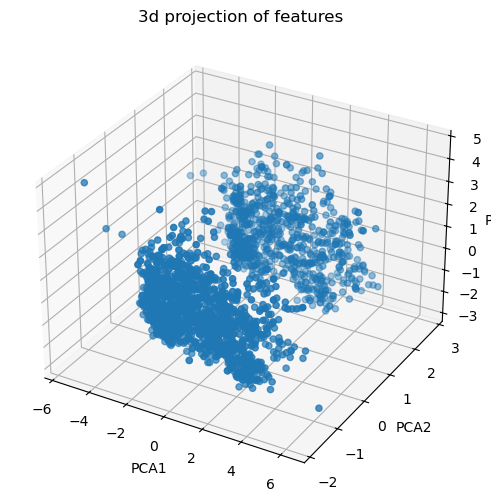

In [78]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection of features")

# Analyze K

In [100]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [101]:
knee = KneeLocator(range(1,11), wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [102]:
print(optimal_k)

4


# Silhouette Score

In [88]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette Score')

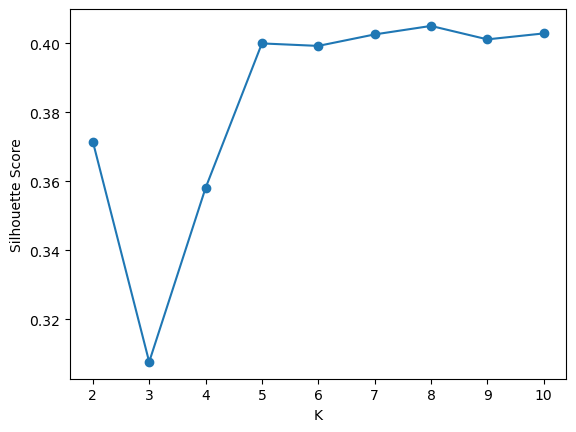

In [89]:
plt.plot(range(2,11) , scores , marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'Silhouette Score')

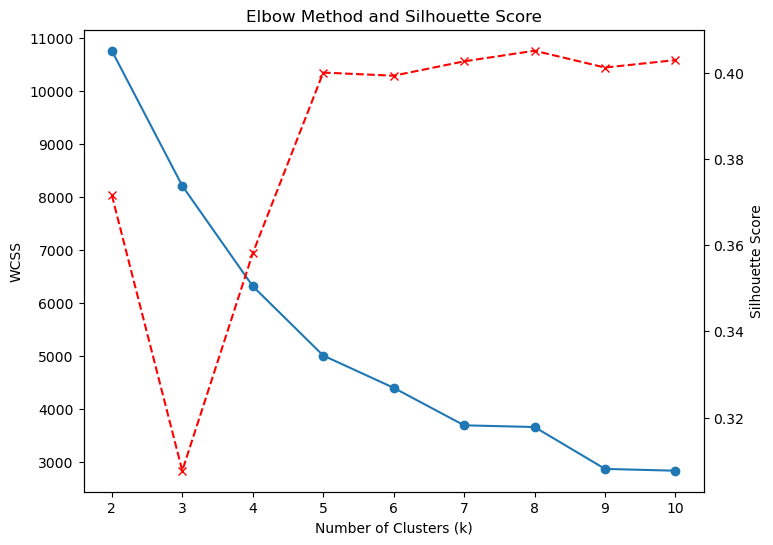

In [105]:
# Combined Plot

k_values = range(2, 11)
wcss_new = wcss[1:]
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_values, wcss_new, marker='o', label='WCSS')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("WCSS")
ax1.set_title("Elbow Method and Silhouette Score")

ax2 = ax1.twinx()

ax2.plot(k_values, scores, marker='x', linestyle='--', label='Silhouette Score',color='red')
ax2.set_ylabel("Silhouette Score")

# Clustering

In [106]:
#Kmeans

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection of features')

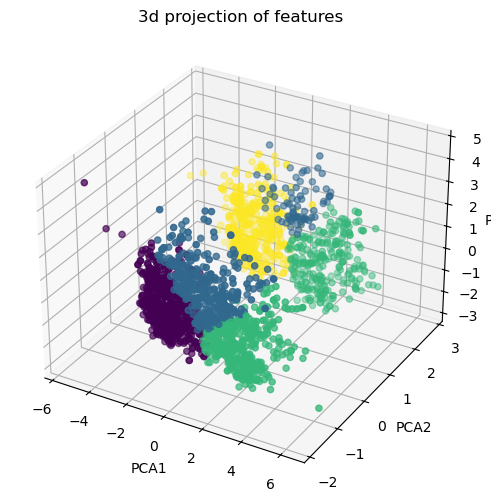

In [107]:
#Visualize

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection of features")

In [108]:
#Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

In [111]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_aggclf = agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection of features')

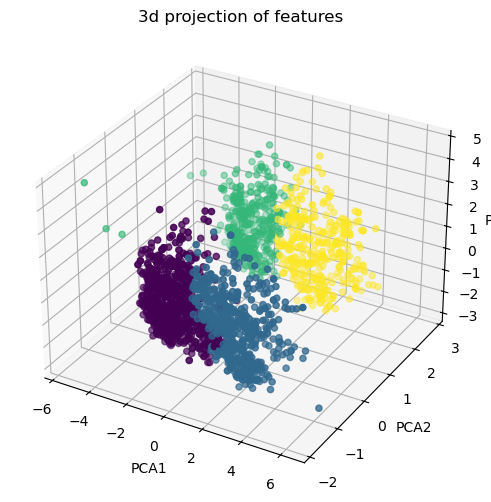

In [112]:
#Visualize

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_aggclf)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection of features")

# Characterization of Clusters

In [130]:
X["cluster"] = labels_aggclf

In [131]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

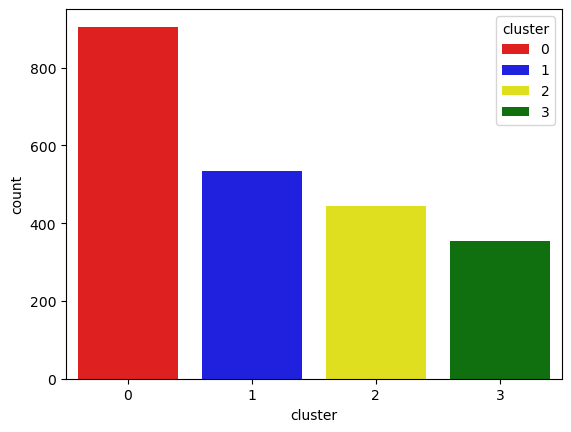

In [132]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

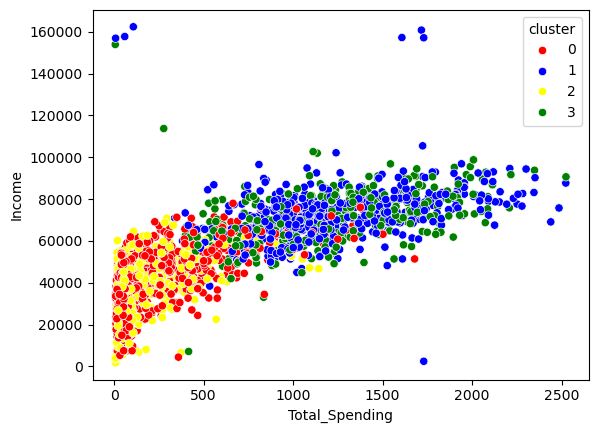

In [133]:
#Income and TotalSpending

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue = X["cluster"],palette=pal)

# Cluster Summary

In [134]:
cluster_summary = X.groupby("cluster").mean()

print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         